<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 5 Day 1: Unsupervised Learning & K-Means Clustering
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 1 Learning Objectives:</b>
-  <b>Unsupervised Foundations:</b> Discover hidden structure and natural clusters in data without relying on target labels ($y$).
-  <b>Feature Scaling Discipline:</b> Apply `StandardScaler` to prevent large-magnitude clinical features from dominating Euclidean distance calculations.
-  <b>The Elbow Method:</b> Run K-Means across $k \in [1, 10]$ and track within-cluster inertia to locate the inflection point.
-  <b>Silhouette Score Validation:</b> Quantitatively validate cluster cohesion and separation across candidate $k$ values.
-  <b>Clinical Interpretation:</b> Fit the final K-Means model, visualize 2D clusters with centroids, and interpret patient risk subgroups.

</blockquote>


## <span style="color: #39b64eff">1.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core numerical and visualization packages alongside Scikit-Learn modules for feature scaling, K-Means clustering, and silhouette evaluation.

</blockquote>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('../../Data/raw/penguins_size.csv')


## <span style="color: #309c42ff">1.2 Dataset Loading & Feature Selection</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Palmer Archipelago Penguins dataset (<code>penguins_size.csv</code>). Since this is an unsupervised task, we drop categorical identifiers and target labels, remove incomplete records with missing values, and isolate the continuous morphological features: <code>culmen_length_mm</code>, <code>culmen_depth_mm</code>, <code>flipper_length_mm</code>, and <code>body_mass_g</code> to construct the feature matrix $X$.

</blockquote>


In [2]:
df = df.dropna()

numeric_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[numeric_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## <span style="color: #309c42ff">1.3 Feature Scaling Discipline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Always scale features before clustering. K-Means uses Euclidean distance, so an unscaled large-range feature (like `body_mass_g` spanning 2700g to 6300g) would dominate a small-range one (like `culmen_depth_mm` spanning 13mm to 21mm). We apply `StandardScaler` to standardize all features to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

</blockquote>


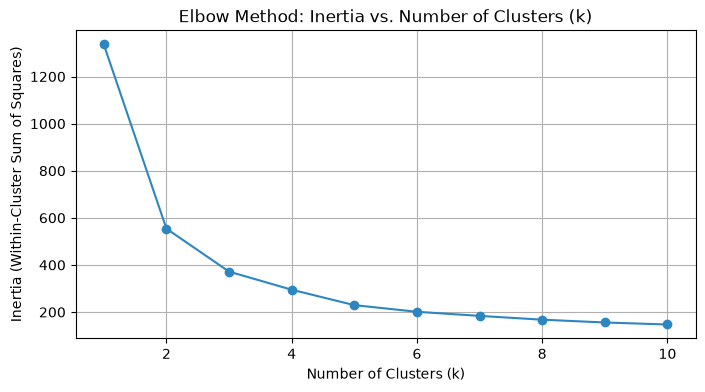

In [3]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='#2E86C1')
plt.title('Elbow Method: Inertia vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

## <span style="color: #309c42ff">1.4 Choosing k: The Elbow Method</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

K-Means requires specifying $k$ in advance, but the right $k$ is rarely obvious. The Elbow Method runs K-Means for a range of $k$ values ($k \in [1, 10]$) and plots the <b>Inertia</b> (total within-cluster sum of squares) against $k$. Inertia always falls as $k$ rises, but the rate of improvement drops sharply at the right $k$ — creating an "elbow" in the plot that indicates the recommended $k$.

</blockquote>


In [4]:
candidate_k = [2, 3, 4, 5]
silhouette_scores = {}

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"k = {k} -> Silhouette Score: {score:.4f}")

k = 2 -> Silhouette Score: 0.5306
k = 3 -> Silhouette Score: 0.4468
k = 4 -> Silhouette Score: 0.3976
k = 5 -> Silhouette Score: 0.3738


## <span style="color: #309c42ff">1.5 Choosing k: The Silhouette Score</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

The silhouette score provides a quantitative validation: it measures how well each point sits inside its own cluster versus the nearest other cluster, on a scale from $-1.0$ to $+1.0$. A higher average silhouette score indicates better-defined clusters. Comparing the score across candidate $k$ values gives a data-driven confirmation of the elbow.

</blockquote>


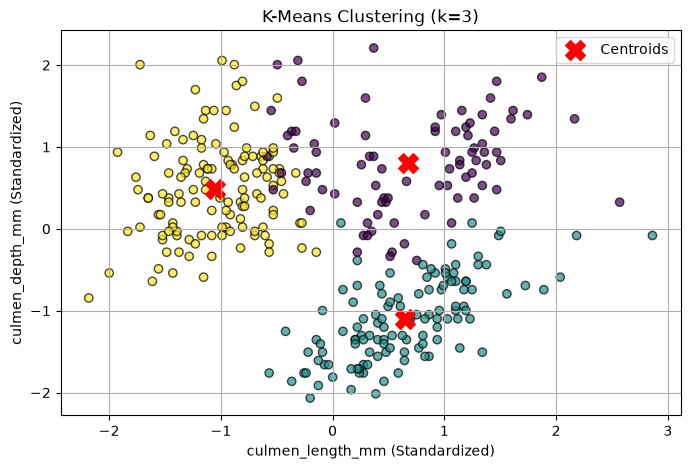

In [5]:
optimal_k = 3
final_km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = final_km.fit_predict(X_scaled)
centroids = final_km.cluster_centers_

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], 
    c=df['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k'
)
plt.scatter(
    centroids[:, 0], centroids[:, 1], 
    c='red', marker='X', s=200, label='Centroids'
)
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.xlabel(f'{numeric_features[0]} (Standardized)')
plt.ylabel(f'{numeric_features[1]} (Standardized)')
plt.legend()
plt.grid(True)
plt.show()

## <span style="color: #309c42ff">1.6 Final Model Fitting & Centroid Visualization</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We fit the final K-Means model using the optimal $k=3$ with `random_state=42` and `n_init=10`. The algorithm iterates through the centroid-assignment loop until convergence: assigning points to the nearest centroid and updating centroids to the mean position of assigned points. We visualize the resulting clusters on a 2D scatter plot with final cluster centroids highlighted.

</blockquote>


In [6]:
cluster_summary = df.groupby('Cluster')[numeric_features].mean()
print("Cluster Profiles (Mean Feature Values):")
print(cluster_summary)

Cluster Profiles (Mean Feature Values):
         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
Cluster                                                                   
0               47.662353        18.748235         196.917647  3898.235294
1               47.542500        15.002500         217.233333  5090.625000
2               38.276744        18.121705         188.627907  3593.798450


## <span style="color: #309c42ff">1.7 Cluster Profiling & Interpretation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Because unsupervised learning lacks ground-truth labels, extracting meaningful insight requires computing summary statistics for each cluster on the original feature scale. We group the dataset by the discovered cluster labels and compute mean feature values to profile each subgroup:

- <b>Cluster 0:</b> Moderate body mass with long and deep bills.
- <b>Cluster 1:</b> Heavyweight subgroup characterized by maximum body mass, long flippers, and shallow bill depth.
- <b>Cluster 2:</b> Compact subgroup characterized by shorter bills, deep bill depth, and lower average body mass.

</blockquote>
